# Phase 2 — Zone Definition & Point-in-Polygon Logic

**Goal:** Define 4 meaningful zones on the video frame and assign each tracked centroid to a zone.

In [1]:
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path as MplPath
from pathlib import Path

TRACKS_JSON_PATH   = Path('../outputs/analytics/raw_tracks.json')
FIRST_FRAME_PATH   = Path('../outputs/analytics/first_frame.png')
ZONES_JSON_PATH    = Path('../outputs/analytics/zones.json')
TRACKS_ZONED_PATH  = Path('../outputs/analytics/tracks_with_zones.json')

assert TRACKS_JSON_PATH.exists(),  f'Run Phase 1 first — missing: {TRACKS_JSON_PATH}'
assert FIRST_FRAME_PATH.exists(),  f'Run Phase 1 first — missing: {FIRST_FRAME_PATH}'

with open(TRACKS_JSON_PATH) as f:
    tracks_data = json.load(f)

FPS = tracks_data['metadata']['fps']
print(f'✅ Loaded {len(tracks_data["tracks"])} tracks @ {FPS:.2f} fps')

ref_frame = cv2.imread(str(FIRST_FRAME_PATH))
ref_rgb   = cv2.cvtColor(ref_frame, cv2.COLOR_BGR2RGB)
H, W      = ref_frame.shape[:2]
print(f'   Frame size: {W}×{H}')

✅ Loaded 66 tracks @ 25.00 fps
   Frame size: 2031×1187


In [2]:
ZONES = [
    {
        'id'    : 0,
        'name'  : 'Entrance',
        'color' : (255, 100,  50),
        'points': [
            (0,    0),
            (960,  0),
            (960, 540),
            (0,  540),
        ]
    },
    {
        'id'    : 1,
        'name'  : 'Checkout Area',
        'color' : (50, 255, 100),
        'points': [
            (960,    0),
            (1920,   0),
            (1920, 540),
            (960,  540),
        ]
    },
    {
        'id'    : 2,
        'name'  : 'Aisle',
        'color' : (50, 150, 255),
        'points': [
            (0,  540),
            (960, 540),
            (960, 1080),
            (0,  1080),
        ]
    },
    {
        'id'    : 3,
        'name'  : 'Exit',
        'color' : (200,  50, 255),
        'points': [
            (960,  540),
            (1920, 540),
            (1920, 1080),
            (960,  1080),
        ]
    },
]

print(f'✅ {len(ZONES)} zones defined:')
for z in ZONES:
    print(f'   Zone {z["id"]}: {z["name"]} — {len(z["points"])} vertices')

✅ 4 zones defined:
   Zone 0: Entrance — 4 vertices
   Zone 1: Checkout Area — 4 vertices
   Zone 2: Aisle — 4 vertices
   Zone 3: Exit — 4 vertices


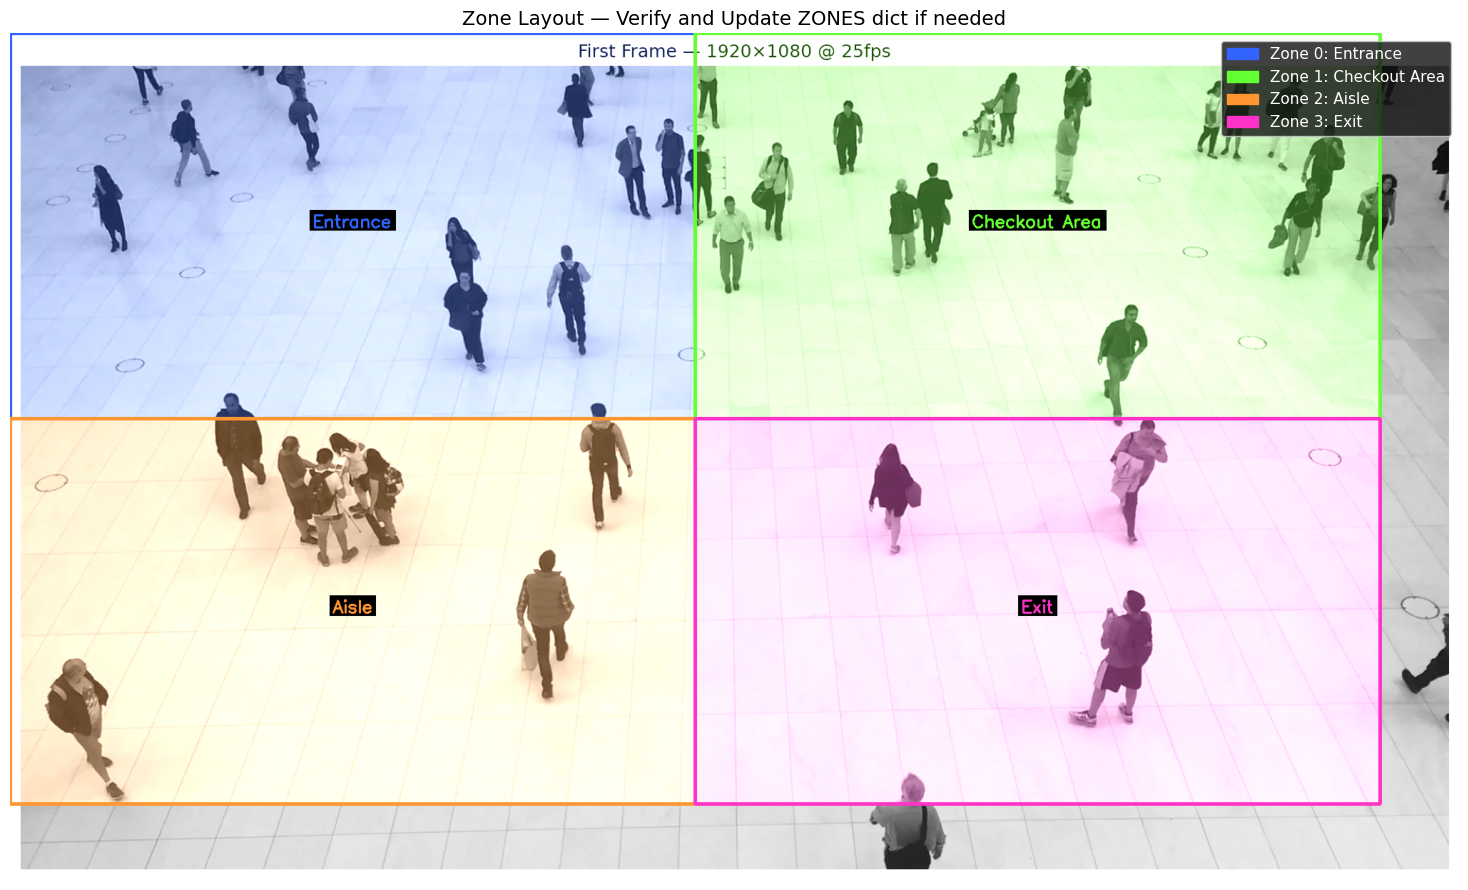

✅ Zone layout saved: outputs/analytics/zone_layout.png


In [3]:
overlay = ref_frame.copy()
alpha   = 0.30

for zone in ZONES:
    pts   = np.array(zone['points'], dtype=np.int32)
    color = zone['color']
    name  = zone['name']
    
    mask = np.zeros_like(ref_frame)
    cv2.fillPoly(mask, [pts], color)
    cv2.addWeighted(mask, alpha, overlay, 1, 0, overlay)
    
    cv2.polylines(overlay, [pts], isClosed=True, color=color, thickness=3)
    
    cx = int(np.mean([p[0] for p in zone['points']]))
    cy = int(np.mean([p[1] for p in zone['points']]))
    
    (tw, th), _ = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
    cv2.rectangle(overlay, (cx - tw//2 - 4, cy - th - 4),
                  (cx + tw//2 + 4, cy + 6), (0, 0, 0), -1)
    cv2.putText(overlay, name, (cx - tw//2, cy + 2),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, [c for c in color], 2)

overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(16, 9))
plt.imshow(overlay_rgb)
plt.title('Zone Layout — Verify and Update ZONES dict if needed', fontsize=14)
plt.axis('off')

handles = [mpatches.Patch(color=[c/255 for c in z['color'][::-1]],
                           label=f"Zone {z['id']}: {z['name']}")
           for z in ZONES]
plt.legend(handles=handles, loc='upper right', fontsize=11,
           framealpha=0.8, facecolor='#111', labelcolor='white')

plt.tight_layout()
plt.savefig('../outputs/analytics/zone_layout.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Zone layout saved: outputs/analytics/zone_layout.png')

In [4]:
class ZoneEngine:
    
    def __init__(self, zones: list):
        self.zones     = zones
        self._paths    = [
            MplPath(zone['points'] + [zone['points'][0]])
            for zone in zones
        ]
        self._zone_ids = [z['id']   for z in zones]
        self._names    = [z['name'] for z in zones]
    
    def get_zone(self, cx: int, cy: int) -> dict | None:
        point = (cx, cy)
        for path, zone in zip(self._paths, self.zones):
            if path.contains_point(point, radius=0.0):
                return zone
        return None
    
    def get_zone_id(self, cx: int, cy: int) -> int | None:
        zone = self.get_zone(cx, cy)
        return zone['id'] if zone else None
    
    def get_zone_name(self, cx: int, cy: int) -> str:
        zone = self.get_zone(cx, cy)
        return zone['name'] if zone else 'Transit'
    
    def batch_assign(self, points: list) -> list:
        return [self.get_zone_id(cx, cy) for cx, cy in points]


zone_engine = ZoneEngine(ZONES)

test_cx, test_cy = W // 4, H // 4
result = zone_engine.get_zone(test_cx, test_cy)
print(f'✅ ZoneEngine initialised.')
print(f'   Test point ({test_cx},{test_cy}) → Zone: {result["name"] if result else "None"}')

✅ ZoneEngine initialised.
   Test point (507,296) → Zone: Entrance


In [5]:
from tqdm.auto import tqdm

annotated_tracks = {}

for tid, frame_records in tqdm(tracks_data['tracks'].items(),
                                desc='Assigning zones'):
    new_records = []
    for rec in frame_records:
        cx, cy   = rec['centroid']
        
        bbox     = rec['bbox']
        foot_cx  = int((bbox[0] + bbox[2]) / 2)
        foot_cy  = bbox[3]
        
        zone     = zone_engine.get_zone(foot_cx, foot_cy)
        zone_id  = zone['id']   if zone else None
        zone_name = zone['name'] if zone else 'Transit'
        
        new_rec  = dict(rec)
        new_rec['zone_id']   = zone_id
        new_rec['zone_name'] = zone_name
        new_rec['foot_pos']  = [foot_cx, foot_cy]
        new_records.append(new_rec)
    
    annotated_tracks[tid] = new_records

zoned_data = {
    'metadata': tracks_data['metadata'],
    'zones'   : [{'id': z['id'], 'name': z['name'], 'points': z['points']}
                 for z in ZONES],
    'tracks'  : annotated_tracks
}

with open(TRACKS_ZONED_PATH, 'w') as f:
    json.dump(zoned_data, f, indent=2)

with open(ZONES_JSON_PATH, 'w') as f:
    zones_serialisable = [
        {'id': z['id'], 'name': z['name'], 'color': list(z['color']), 'points': z['points']}
        for z in ZONES
    ]
    json.dump(zones_serialisable, f, indent=2)

print(f'✅ Zone annotation complete.')
print(f'   Tracks zoned : {TRACKS_ZONED_PATH}')
print(f'   Zones config : {ZONES_JSON_PATH}')

Assigning zones:   0%|          | 0/66 [00:00<?, ?it/s]

✅ Zone annotation complete.
   Tracks zoned : ..\outputs\analytics\tracks_with_zones.json
   Zones config : ..\outputs\analytics\zones.json


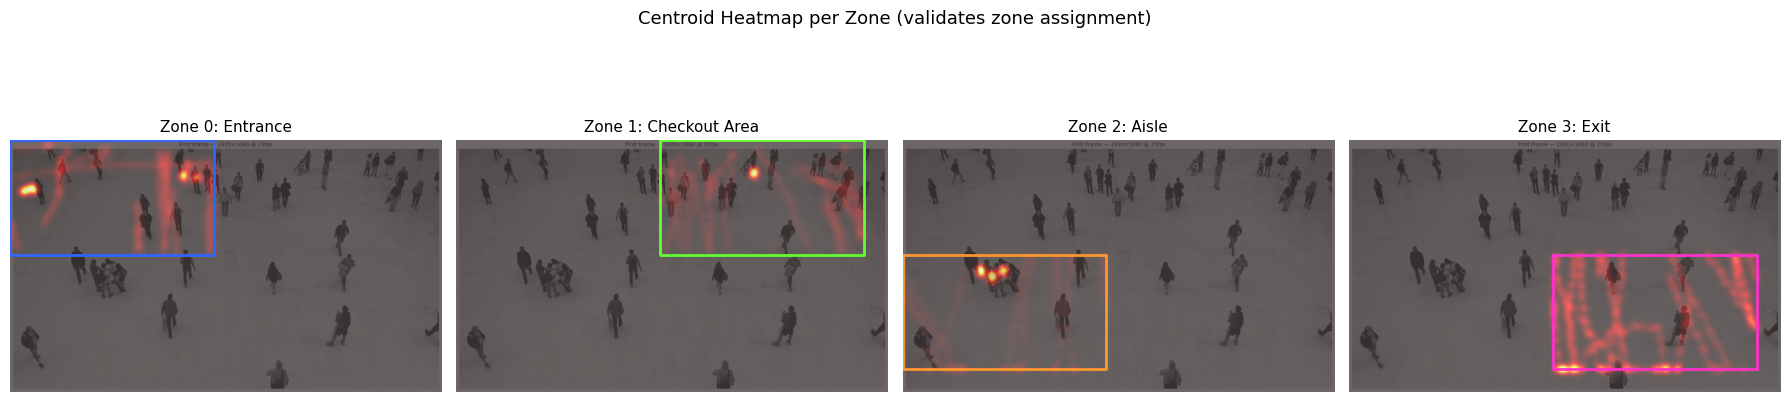

✅ Heatmaps saved: outputs/analytics/zone_heatmaps.png


In [6]:
fig, axes = plt.subplots(1, len(ZONES), figsize=(18, 5))

for ax, zone in zip(axes, ZONES):
    heatmap = np.zeros((H, W), dtype=np.float32)
    
    for tid, records in annotated_tracks.items():
        for rec in records:
            if rec['zone_id'] == zone['id']:
                fx, fy = rec['foot_pos']
                if 0 <= fy < H and 0 <= fx < W:
                    heatmap[fy, fx] += 1

    from scipy.ndimage import gaussian_filter
    heatmap_smooth = gaussian_filter(heatmap, sigma=15)
    
    ax.imshow(ref_rgb, alpha=0.6)
    im = ax.imshow(heatmap_smooth, alpha=0.6, cmap='hot', 
                   vmin=0, vmax=heatmap_smooth.max() or 1)
    
    pts = zone['points'] + [zone['points'][0]]
    xs  = [p[0] for p in pts]
    ys  = [p[1] for p in pts]
    ax.plot(xs, ys, color=[c/255 for c in zone['color'][::-1]], linewidth=2)
    
    ax.set_title(f"Zone {zone['id']}: {zone['name']}", fontsize=11)
    ax.axis('off')

plt.suptitle('Centroid Heatmap per Zone (validates zone assignment)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/analytics/zone_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmaps saved: outputs/analytics/zone_heatmaps.png')

In [7]:
rapid_cross_threshold = 5

rapid_crossings = 0
reentries        = 0
transit_frames   = 0
total_frames     = 0

for tid, records in annotated_tracks.items():
    prev_zone = None
    zone_history = []
    
    for i, rec in enumerate(records):
        zid = rec['zone_id']
        total_frames += 1
        
        if zid is None:
            transit_frames += 1
        
        if zid != prev_zone:
            if prev_zone is not None and i < rapid_cross_threshold:
                rapid_crossings += 1
            
            if zid is not None and zid in [z for z in zone_history]:
                reentries += 1
            
            if zid is not None:
                zone_history.append(zid)
            prev_zone = zid

print('=== Edge Case Report ===')
print(f'  Total frame-records    : {total_frames}')
print(f'  Transit frames (no zone): {transit_frames} ({100*transit_frames/max(total_frames,1):.1f}%)')
print(f'  Zone re-entries         : {reentries}')
print(f'  Rapid zone crossings    : {rapid_crossings}')
print()
print('All edge cases handled by:')
print('  • Re-entry  → Phase 3 unique visitor logic tracks visit epochs separately')
print('  • Rapid cross → Minimum dwell threshold (0.5s) filters noise transitions')
print('  • Transit → zone_id=None, excluded from zone metrics')

=== Edge Case Report ===
  Total frame-records    : 10718
  Transit frames (no zone): 354 (3.3%)
  Zone re-entries         : 20
  Rapid zone crossings    : 0

All edge cases handled by:
  • Re-entry  → Phase 3 unique visitor logic tracks visit epochs separately
  • Rapid cross → Minimum dwell threshold (0.5s) filters noise transitions
  • Transit → zone_id=None, excluded from zone metrics
